Accuracy: 0.9032258064516129
Error Rate: 0.09677419354838712


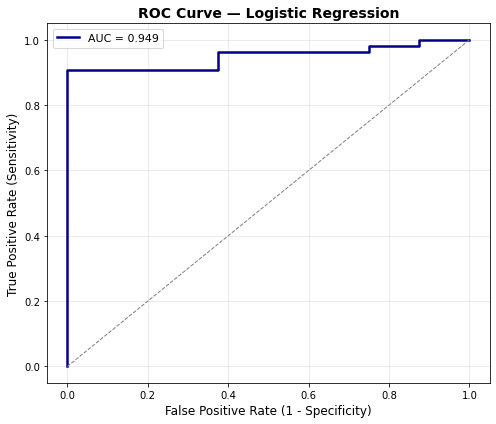

ROC AUC Score: 0.9490740740740741

Sensitivity: 0.9629629629629629
Specificity: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.93      0.96      0.95        54

    accuracy                           0.90        62
   macro avg       0.80      0.73      0.76        62
weighted avg       0.89      0.90      0.90        62


Feature Importance:
                   Feature  Importance
7                FATIGUE     1.460646
8                ALLERGY     1.451985
6         CHRONIC DISEASE    1.423098
10      ALCOHOL CONSUMING    1.370438
5           PEER_PRESSURE    1.296486
13  SWALLOWING DIFFICULTY    1.082735
11               COUGHING    0.893073
3          YELLOW_FINGERS    0.883705
9                WHEEZING    0.809564
2                 SMOKING    0.644746
4                 ANXIETY    0.611011
14             CHEST PAIN    0.514265
12    SHORTNESS OF BREATH    0.052230
1          

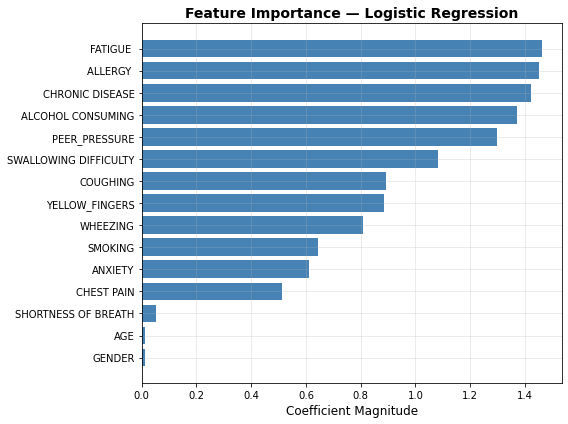

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================
# 4. Train Logistic Regression
# ============================
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# ============================
# 5. Predictions
# ============================
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 7. ROC Curve (Professional)
# ============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve — Logistic Regression", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("ROC AUC Score:", roc_auc)

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
# 10. Feature Importance Table
# ============================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(lr_model.coef_[0])
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance)

# ============================
# 11. Feature Importance Plot (Blue)
# ============================
plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.xlabel("Coefficient Magnitude", fontsize=12)
plt.title("Feature Importance — Logistic Regression", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# SVM

Accuracy: 0.9032258064516129
Error Rate: 0.09677419354838712


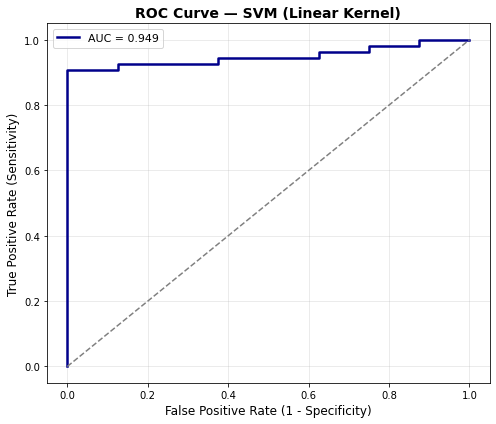

ROC AUC Score: 0.9490740740740742

Sensitivity: 0.9444444444444444
Specificity: 0.625

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.94      0.94      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.78      0.78        62
weighted avg       0.90      0.90      0.90        62


Feature Importance:
                   Feature  Importance
6         CHRONIC DISEASE    1.345315
7                FATIGUE     1.176932
5           PEER_PRESSURE    1.154430
10      ALCOHOL CONSUMING    1.042883
8                ALLERGY     0.930152
11               COUGHING    0.873418
3          YELLOW_FINGERS    0.824645
9                WHEEZING    0.823277
13  SWALLOWING DIFFICULTY    0.760758
2                 SMOKING    0.753329
14             CHEST PAIN    0.493055
4                 ANXIETY    0.344386
12    SHORTNESS OF BREATH    0.247968
0        

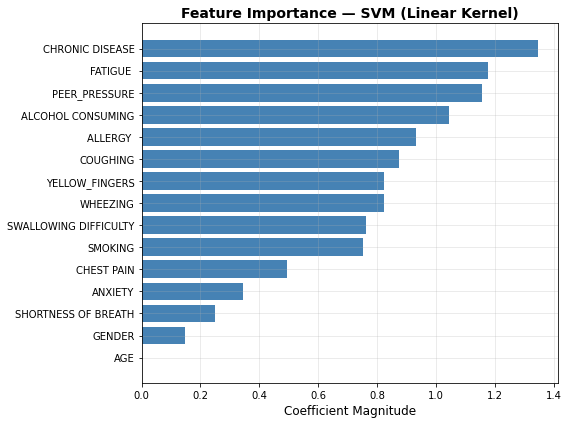

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================
# 4. Train SVM (Linear Kernel)
# ============================
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# ============================
# 5. Predictions
# ============================
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 7. ROC Curve (Professional)
# ============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve — SVM (Linear Kernel)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("ROC AUC Score:", roc_auc)

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
# 10. Feature Importance (Coefficients)
# ============================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(svm_model.coef_[0])   # FIXED HERE
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance)

# ============================
# 11. Feature Importance Plot (Blue)
# ============================
plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.xlabel("Coefficient Magnitude", fontsize=12)
plt.title("Feature Importance — SVM (Linear Kernel)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# DECISION TREE

Accuracy: 0.8709677419354839
Error Rate: 0.12903225806451613


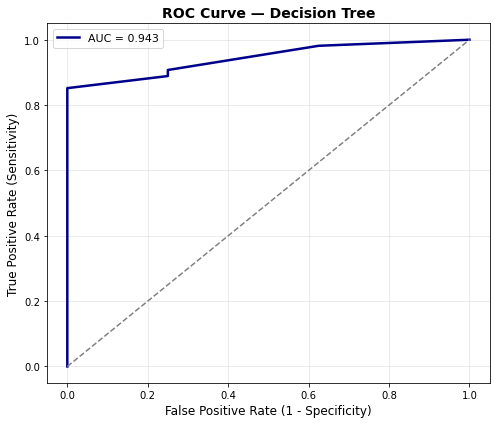


Sensitivity: 0.8888888888888888
Specificity: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.75      0.60         8
           1       0.96      0.89      0.92        54

    accuracy                           0.87        62
   macro avg       0.73      0.82      0.76        62
weighted avg       0.90      0.87      0.88        62


Feature Importance:
                   Feature  Importance
8                ALLERGY     0.223811
5           PEER_PRESSURE    0.216398
13  SWALLOWING DIFFICULTY    0.200344
10      ALCOHOL CONSUMING    0.199221
1                     AGE    0.088637
7                FATIGUE     0.064153
3          YELLOW_FINGERS    0.007437
0                  GENDER    0.000000
2                 SMOKING    0.000000
4                 ANXIETY    0.000000
6         CHRONIC DISEASE    0.000000
9                WHEEZING    0.000000
11               COUGHING    0.000000
12    SHORTNESS OF BREATH    0.000000
14    

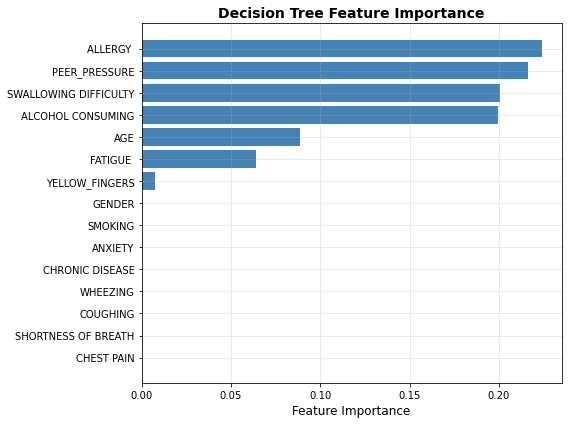

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 4. Train Decision Tree
# ============================
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# ============================
# 5. Predictions
# ============================
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 7. ROC Curve
# ============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve — Decision Tree", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
# 10. Feature Importance Table
# ============================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance)

# ============================
# 11. Feature Importance Plot
# ============================
plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Decision Tree Feature Importance", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

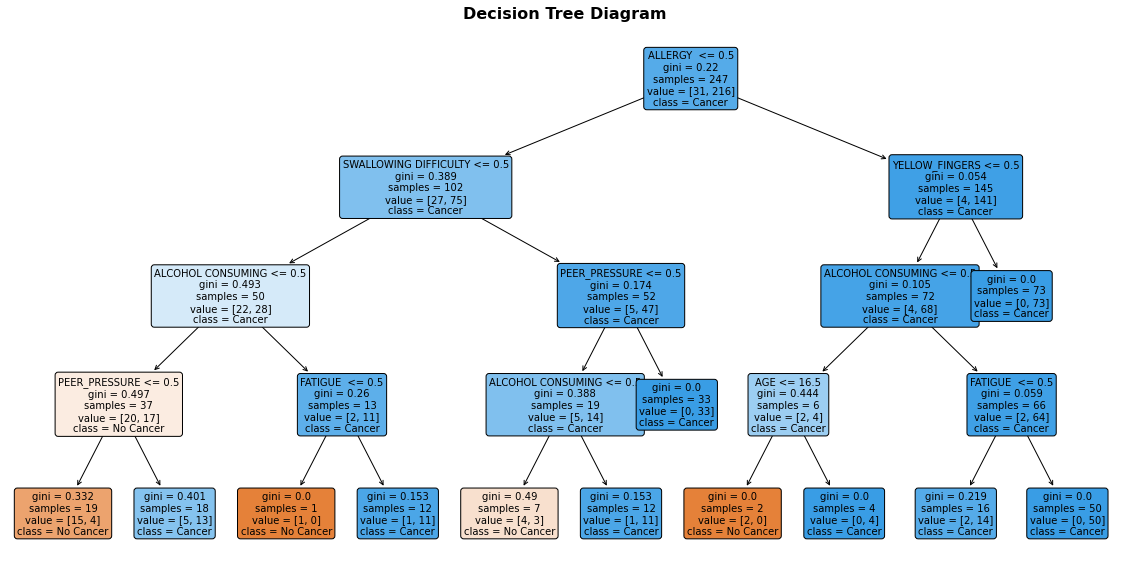

In [15]:
# ============================
# 12. Decision Tree Diagram
# ============================
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Cancer", "Cancer"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Diagram", fontsize=16, fontweight="bold")
plt.show()

# DECISION TREE

Accuracy: 0.9193548387096774
Error Rate: 0.08064516129032262


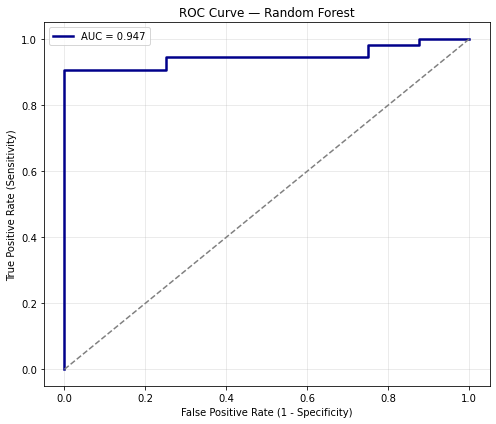


Sensitivity: 0.9444444444444444
Specificity: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71         8
           1       0.96      0.94      0.95        54

    accuracy                           0.92        62
   macro avg       0.81      0.85      0.83        62
weighted avg       0.92      0.92      0.92        62


Feature Importance:
                   Feature  Importance
1                     AGE    0.203876
8                ALLERGY     0.089843
10      ALCOHOL CONSUMING    0.084597
5           PEER_PRESSURE    0.079557
3          YELLOW_FINGERS    0.065880
7                FATIGUE     0.054911
6         CHRONIC DISEASE    0.054584
9                WHEEZING    0.053888
11               COUGHING    0.051477
4                 ANXIETY    0.047870
12    SHORTNESS OF BREATH    0.046780
14             CHEST PAIN    0.043734
13  SWALLOWING DIFFICULTY    0.043291
0                  GENDER    0.040804
2     

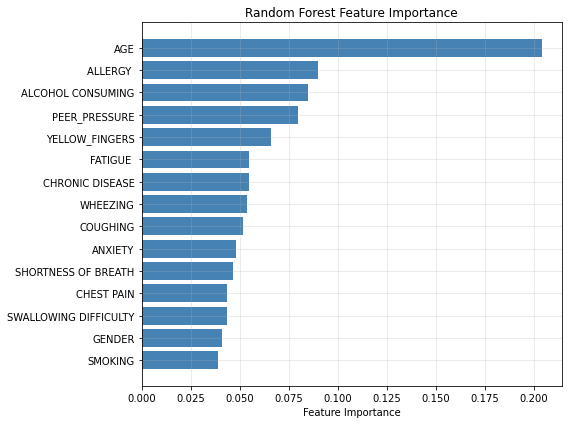

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 4. Train Random Forest (NO TUNING)
# ============================
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

# ============================
# 5. Predictions
# ============================
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 7. ROC Curve
# ============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Random Forest")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
# 10. Feature Importance
# ============================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance)

# ============================
# 11. Feature Importance Plot
# ============================
plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Best Parameters: {'splitter': 'random', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 4, 'criterion': 'entropy'}
Accuracy: 0.8548387096774194
Error Rate: 0.14516129032258063


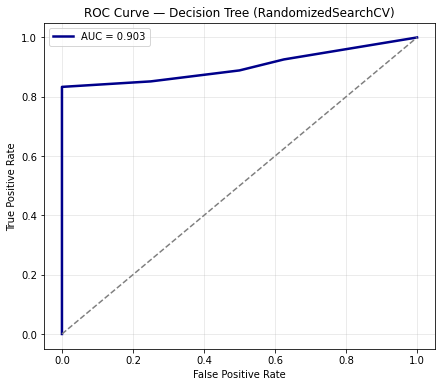

Sensitivity: 0.9259259259259259
Specificity: 0.375

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.38      0.40         8
           1       0.91      0.93      0.92        54

    accuracy                           0.85        62
   macro avg       0.67      0.65      0.66        62
weighted avg       0.85      0.85      0.85        62


Feature Importance:
                  Feature  Importance
8                ALLERGY     0.313492
10      ALCOHOL CONSUMING    0.184824
7                FATIGUE     0.164924
13  SWALLOWING DIFFICULTY    0.159977
5           PEER_PRESSURE    0.099825
3          YELLOW_FINGERS    0.055816
2                 SMOKING    0.021143
0                  GENDER    0.000000
1                     AGE    0.000000
4                 ANXIETY    0.000000
6         CHRONIC DISEASE    0.000000
9                WHEEZING    0.000000
11               COUGHING    0.000000
12    SHORTNESS OF BREATH    0.000000
14     

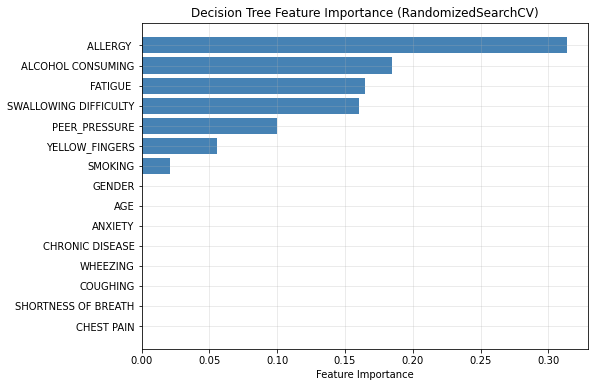

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 4. RandomizedSearchCV (More Stable)
# ============================
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "splitter": ["best", "random"]
}

dt = DecisionTreeClassifier(random_state=42)

rand_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=10,         # Only 10 random combinations → stable & fast
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

rand_search.fit(X_train, y_train)

best_dt = rand_search.best_estimator_

print("\nBest Parameters:", rand_search.best_params_)

# ============================
# 5. Predictions
# ============================
y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Error Rate:", 1 - accuracy)

# ============================
# 7. ROC Curve
# ============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree (RandomizedSearchCV)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Sensitivity:", tp / (tp + fn))
print("Specificity:", tn / (tn + fp))

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
# 10. Feature Importance
# ============================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance (RandomizedSearchCV)")
plt.grid(alpha=0.3)
plt.show()

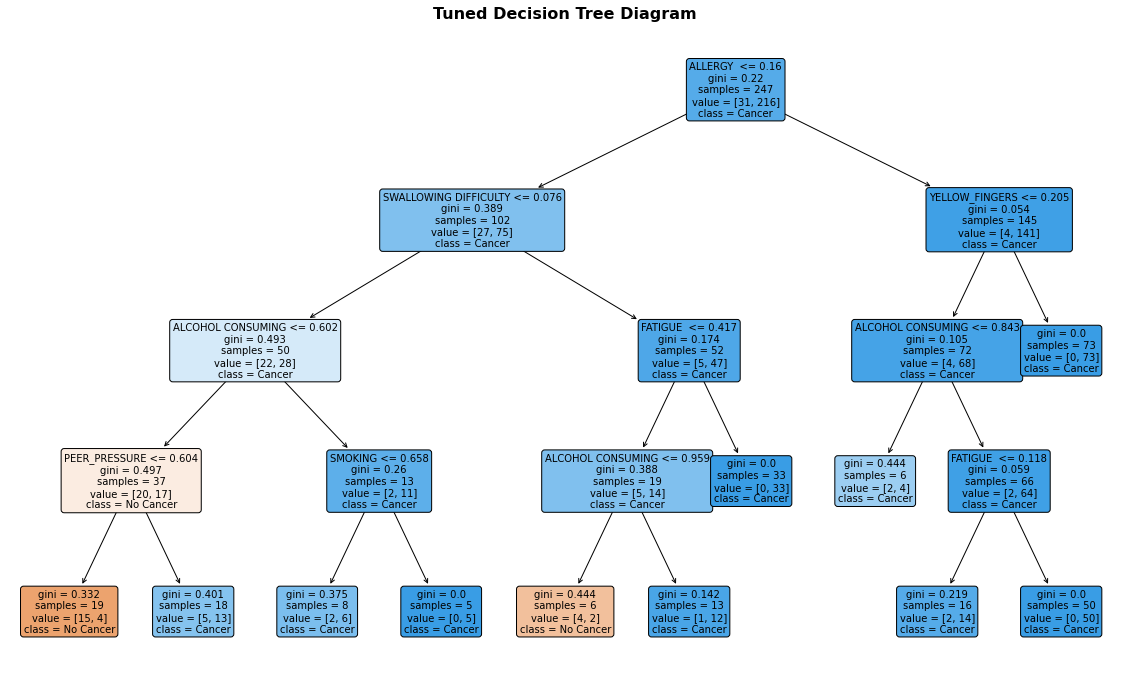

In [22]:
# ============================
# 12. Decision Tree Diagram
# ============================
plt.figure(figsize=(20,12))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["No Cancer", "Cancer"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Tuned Decision Tree Diagram", fontsize=16, fontweight="bold")
plt.show()

Fitting 5 folds for each of 972 candidates, totalling 4860 fits

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 2, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Accuracy: 0.8870967741935484
Error Rate: 0.11290322580645162


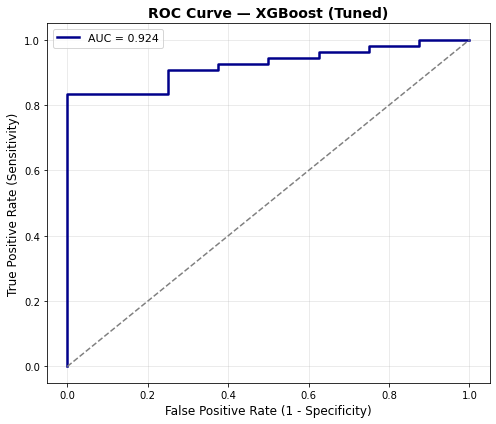


Sensitivity: 0.9444444444444444
Specificity: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.50      0.53         8
           1       0.93      0.94      0.94        54

    accuracy                           0.89        62
   macro avg       0.75      0.72      0.73        62
weighted avg       0.88      0.89      0.88        62


Feature Importance:
                   Feature  Importance
8                ALLERGY     0.111173
3          YELLOW_FINGERS    0.107350
10      ALCOHOL CONSUMING    0.093576
13  SWALLOWING DIFFICULTY    0.086911
5           PEER_PRESSURE    0.077581
9                WHEEZING    0.068874
0                  GENDER    0.060926
6         CHRONIC DISEASE    0.057876
7                FATIGUE     0.057777
11               COUGHING    0.053138
12    SHORTNESS OF BREATH    0.048820
14             CHEST PAIN    0.048251
1                     AGE    0.047421
2                 SMOKING    0.041771
4      

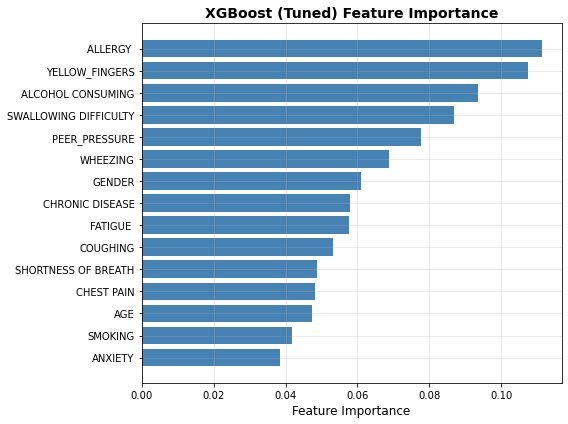

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)
from xgboost import XGBClassifier

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 4. Hyperparameter Tuning (GridSearchCV)
# ============================
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 1, 2]
}

xgb = XGBClassifier(eval_metric="logloss", random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# ============================
# 5. Predictions
# ============================
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 7. ROC Curve (Professional)
# ============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve — XGBoost (Tuned)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
# 10. Feature Importance Table
# ============================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance)

# ============================
# 11. Feature Importance Plot (Blue)
# ============================
plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.xlabel("Feature Importance", fontsize=12)
plt.title("XGBoost (Tuned) Feature Importance", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ANN

Accuracy: 0.8870967741935484
Error Rate: 0.11290322580645162


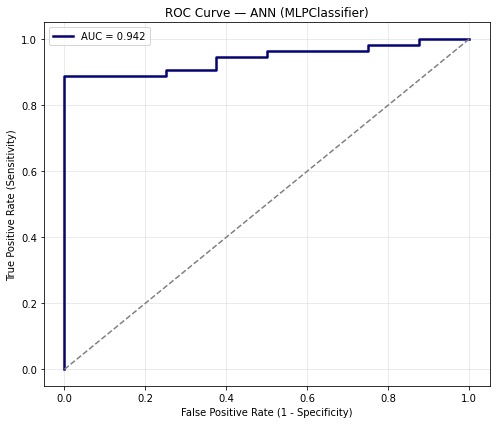


Confusion Matrix:
 [[ 5  3]
 [ 4 50]]
Sensitivity: 0.9259259259259259
Specificity: 0.625

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.94      0.93      0.93        54

    accuracy                           0.89        62
   macro avg       0.75      0.78      0.76        62
weighted avg       0.89      0.89      0.89        62



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 4. Scaling (VERY important for ANN)
# ============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================
# 5. Build ANN (MLPClassifier)
# ============================
ann_model = MLPClassifier(
    hidden_layer_sizes=(16, 12, 8),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# ============================
# 6. Train the Model
# ============================
ann_model.fit(X_train, y_train)

# ============================
# 7. Predictions
# ============================
y_pred = ann_model.predict(X_test)
y_prob = ann_model.predict_proba(X_test)[:, 1]

# ============================
# 8. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 9. ROC Curve
# ============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkblue", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — ANN (MLPClassifier)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# 10. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nConfusion Matrix:\n", cm)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 11. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# NAIVE BAYES

Accuracy: 0.8548387096774194
Error Rate: 0.14516129032258063


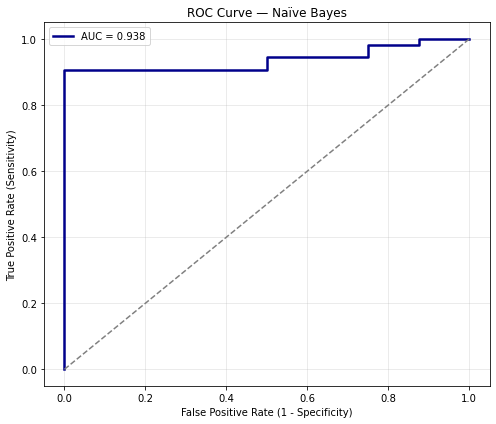


Confusion Matrix:
 [[ 4  4]
 [ 5 49]]
Sensitivity: 0.9074074074074074
Specificity: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.50      0.47         8
           1       0.92      0.91      0.92        54

    accuracy                           0.85        62
   macro avg       0.68      0.70      0.69        62
weighted avg       0.86      0.85      0.86        62



In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 4. Train Naïve Bayes Model
# ============================
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# ============================
# 5. Predictions
# ============================
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

# ============================
# 6. Accuracy & Error
# ============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

# ============================
# 7. ROC Curve
# ============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2.5, color="darkblue", label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Naïve Bayes")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# 8. Sensitivity & Specificity
# ============================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\nConfusion Matrix:\n", cm)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# ============================
# 9. Classification Report
# ============================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



=== Model Comparison ===

                     Accuracy       AUC  Sensitivity  Specificity
Logistic Regression  0.903226  0.949074     0.962963        0.500
SVM                  0.903226  0.949074     0.944444        0.625
Decision Tree        0.870968  0.943287     0.888889        0.750
Random Forest        0.919355  0.946759     0.944444        0.750
XGBoost              0.870968  0.923611     0.907407        0.625
ANN                  0.887097  0.942130     0.925926        0.625
Naive Bayes          0.854839  0.937500     0.907407        0.500


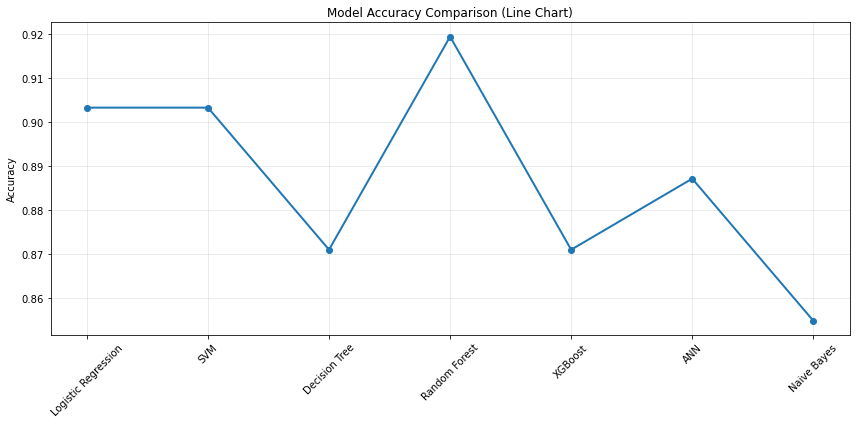

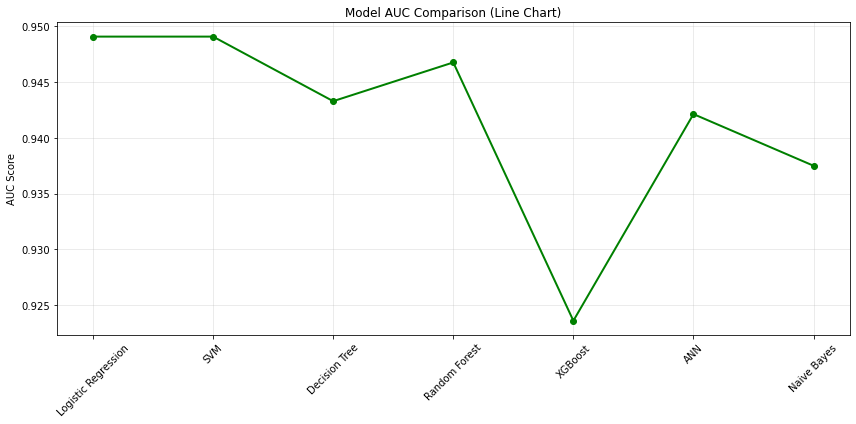

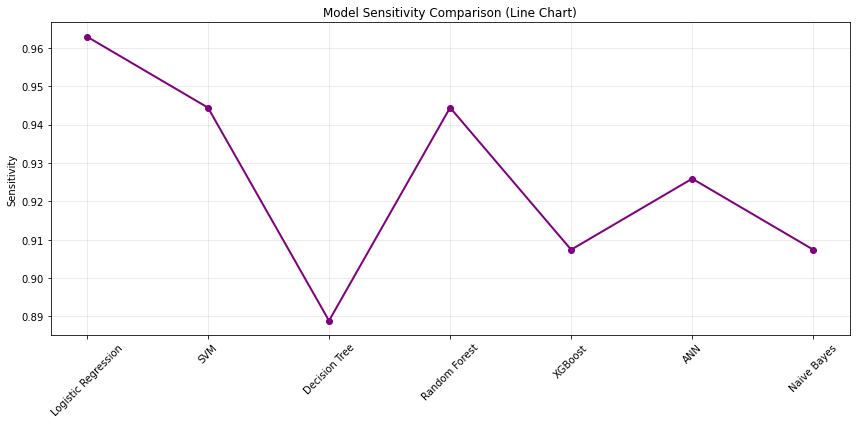

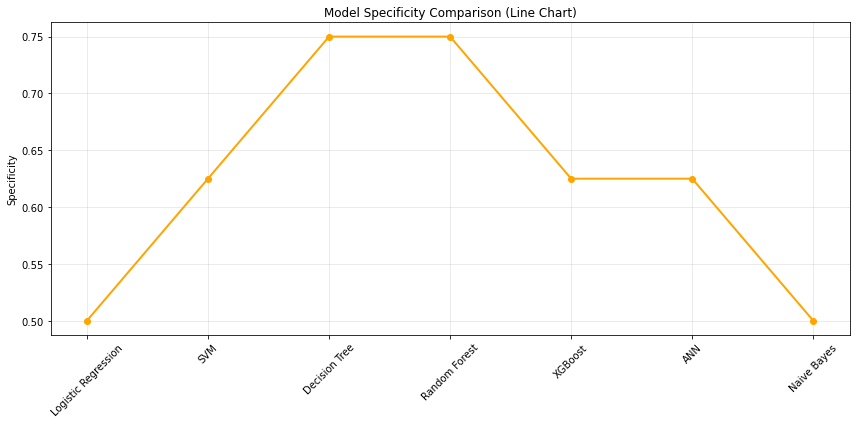

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# =======================================
# 1. Load dataset
# =======================================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# =======================================
# 2. Encode categorical variables
# =======================================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================================
# 3. Models
# =======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(16,12,8), max_iter=500, random_state=42),
    "Naive Bayes": GaussianNB()
}

# =======================================
# 4. Evaluation Function
# =======================================
def evaluate_model(model, scaled=False):
    if scaled:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return accuracy, auc_score, sensitivity, specificity

# =======================================
# 5. Run all models
# =======================================
results = {}

for name, model in models.items():
    scaled = True if name == "ANN" else False
    acc, auc_s, sens, spec = evaluate_model(model, scaled)
    results[name] = [acc, auc_s, sens, spec]

# Final table
comparison_df = pd.DataFrame(
    results,
    index=["Accuracy", "AUC", "Sensitivity", "Specificity"]
).T

print("\n=== Model Comparison ===\n")
print(comparison_df)

# =======================================
# 6. LINE CHARTS
# =======================================

plt.figure(figsize=(12,6))
plt.plot(comparison_df.index, comparison_df["Accuracy"], marker='o', linewidth=2)
plt.title("Model Accuracy Comparison (Line Chart)")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(comparison_df.index, comparison_df["AUC"], marker='o', linewidth=2, color="green")
plt.title("Model AUC Comparison (Line Chart)")
plt.ylabel("AUC Score")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(comparison_df.index, comparison_df["Sensitivity"], marker='o', linewidth=2, color="purple")
plt.title("Model Sensitivity Comparison (Line Chart)")
plt.ylabel("Sensitivity")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(comparison_df.index, comparison_df["Specificity"], marker='o', linewidth=2, color="orange")
plt.title("Model Specificity Comparison (Line Chart)")
plt.ylabel("Specificity")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

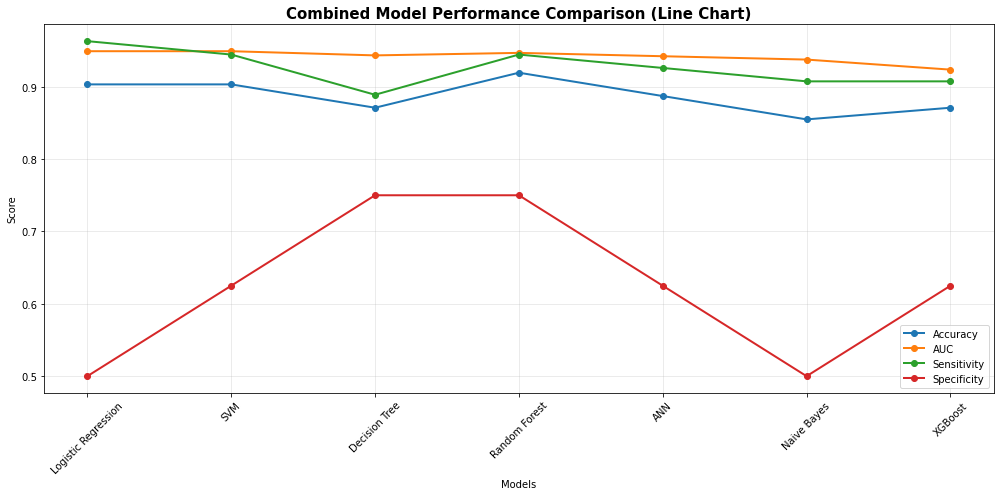

,Accuracy,AUC,Sensitivity,Specificity
Logistic Regression,0.903226,0.949074,0.962963,0.500
SVM,0.903226,0.949074,0.944444,0.625
Decision Tree,0.870968,0.943287,0.888889,0.750
Random Forest,0.919355,0.946759,0.944444,0.750
ANN,0.887097,0.942130,0.925926,0.625
Naive Bayes,0.854839,0.937500,0.907407,0.500
XGBoost,0.870968,0.923611,0.907407,0.625


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Safe XGBoost import
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# Encoding
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# DEFINE MODELS
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear", probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(16, 12, 8), max_iter=500, random_state=42),
    "Naive Bayes": GaussianNB(),
}

# Add XGBoost only if environment supports it
if xgb_available:
    models["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=42)


# ===============================
# EVALUATION FUNCTION
# ===============================
def evaluate_model(model, scaled=False):
    if scaled:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return accuracy, auc_score, sensitivity, specificity


# ===============================
# RUN MODELS
# ===============================
results = {}
for name, model in models.items():
    scaled = True if name == "ANN" else False
    acc, auc_s, sens, spec = evaluate_model(model, scaled)
    results[name] = [acc, auc_s, sens, spec]

comparison_df = pd.DataFrame(
    results,
    index=["Accuracy", "AUC", "Sensitivity", "Specificity"]
).T


# ===============================
# COMBINED LINE CHART
# ===============================
plt.figure(figsize=(14,7))

for metric in comparison_df.columns:
    plt.plot(comparison_df.index, comparison_df[metric], marker='o', linewidth=2, label=metric)

plt.title("Combined Model Performance Comparison (Line Chart)", fontsize=15, fontweight="bold")
plt.xlabel("Models")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

comparison_df


In [59]:
import pandas as pd
from tabulate import tabulate

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Convert AGE into bins
# ============================
bins = [0, 30, 40, 50, 60, 70, 200]
labels = ["<30", "30-40", "40-50", "50-60", "60-70", "70+"]

df["AGE_BIN"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

# ============================
# 3. Cross Tab: AGE_BIN vs LUNG_CANCER
# ============================
crosstab_age = pd.crosstab(df["AGE_BIN"], df["LUNG_CANCER"])
crosstab_age_pct = pd.crosstab(df["AGE_BIN"], df["LUNG_CANCER"], normalize="index") * 100

# ============================
# 4. Print with tabulate (fancy_grid)
# ============================
print("\n=== AGE BIN vs LUNG CANCER ===")
print(tabulate(crosstab_age.reset_index(), headers='keys', tablefmt='fancy_grid', showindex=False))

print("\n=== AGE BIN vs LUNG CANCER (Percentages) ===")
print(tabulate(crosstab_age_pct.reset_index().round(2), headers='keys', tablefmt='fancy_grid', showindex=False))



=== AGE BIN vs LUNG CANCER ===
╒═══════════╤══════╤═══════╕
│ AGE_BIN   │   NO │   YES │
╞═══════════╪══════╪═══════╡
│ <30       │    1 │     0 │
├───────────┼──────┼───────┤
│ 30-40     │    0 │     2 │
├───────────┼──────┼───────┤
│ 40-50     │    2 │    10 │
├───────────┼──────┼───────┤
│ 50-60     │   13 │    78 │
├───────────┼──────┼───────┤
│ 60-70     │   20 │   114 │
├───────────┼──────┼───────┤
│ 70+       │    3 │    66 │
╘═══════════╧══════╧═══════╛

=== AGE BIN vs LUNG CANCER (Percentages) ===
╒═══════════╤════════╤════════╕
│ AGE_BIN   │     NO │    YES │
╞═══════════╪════════╪════════╡
│ <30       │ 100    │   0    │
├───────────┼────────┼────────┤
│ 30-40     │   0    │ 100    │
├───────────┼────────┼────────┤
│ 40-50     │  16.67 │  83.33 │
├───────────┼────────┼────────┤
│ 50-60     │  14.29 │  85.71 │
├───────────┼────────┼────────┤
│ 60-70     │  14.93 │  85.07 │
├───────────┼────────┼────────┤
│ 70+       │   4.35 │  95.65 │
╘═══════════╧════════╧════════╛


In [70]:
from tabulate import tabulate

# ============================
# 4. Cross Tabs for ALL CATEGORICAL VARIABLES vs LUNG_CANCER
# ============================

# Exclude target + numeric columns
categorical_cols = [col for col in df.columns if col not in ["AGE", "AGE_BIN", "LUNG_CANCER"]]

all_crosstabs = {}

print("\n==============================")
print("CROSS TABS FOR ALL CATEGORICAL FEATURES")
print("==============================")

for col in categorical_cols:
    ct = pd.crosstab(df[col], df["LUNG_CANCER"])
    all_crosstabs[col] = ct

    print(f"\n=== {col} vs LUNG_CANCER ===")
    print(
        tabulate(
            ct.reset_index(),
            headers="keys",
            tablefmt="fancy_grid",
            showindex=False
        )
    )

# all_crosstabs contains all crosstab DataFrames if needed later


CROSS TABS FOR ALL CATEGORICAL FEATURES

=== GENDER vs LUNG_CANCER ===
╒══════════╤══════╤═══════╕
│ GENDER   │   NO │   YES │
╞══════════╪══════╪═══════╡
│ F        │   22 │   125 │
├──────────┼──────┼───────┤
│ M        │   17 │   145 │
╘══════════╧══════╧═══════╛

=== SMOKING vs LUNG_CANCER ===
╒═══════════╤══════╤═══════╕
│   SMOKING │   NO │   YES │
╞═══════════╪══════╪═══════╡
│         1 │   20 │   115 │
├───────────┼──────┼───────┤
│         2 │   19 │   155 │
╘═══════════╧══════╧═══════╛

=== YELLOW_FINGERS vs LUNG_CANCER ===
╒══════════════════╤══════╤═══════╕
│   YELLOW_FINGERS │   NO │   YES │
╞══════════════════╪══════╪═══════╡
│                1 │   26 │   107 │
├──────────────────┼──────┼───────┤
│                2 │   13 │   163 │
╘══════════════════╧══════╧═══════╛

=== ANXIETY vs LUNG_CANCER ===
╒═══════════╤══════╤═══════╕
│   ANXIETY │   NO │   YES │
╞═══════════╪══════╪═══════╡
│         1 │   27 │   128 │
├───────────┼──────┼───────┤
│         2 │   12 │   142 │


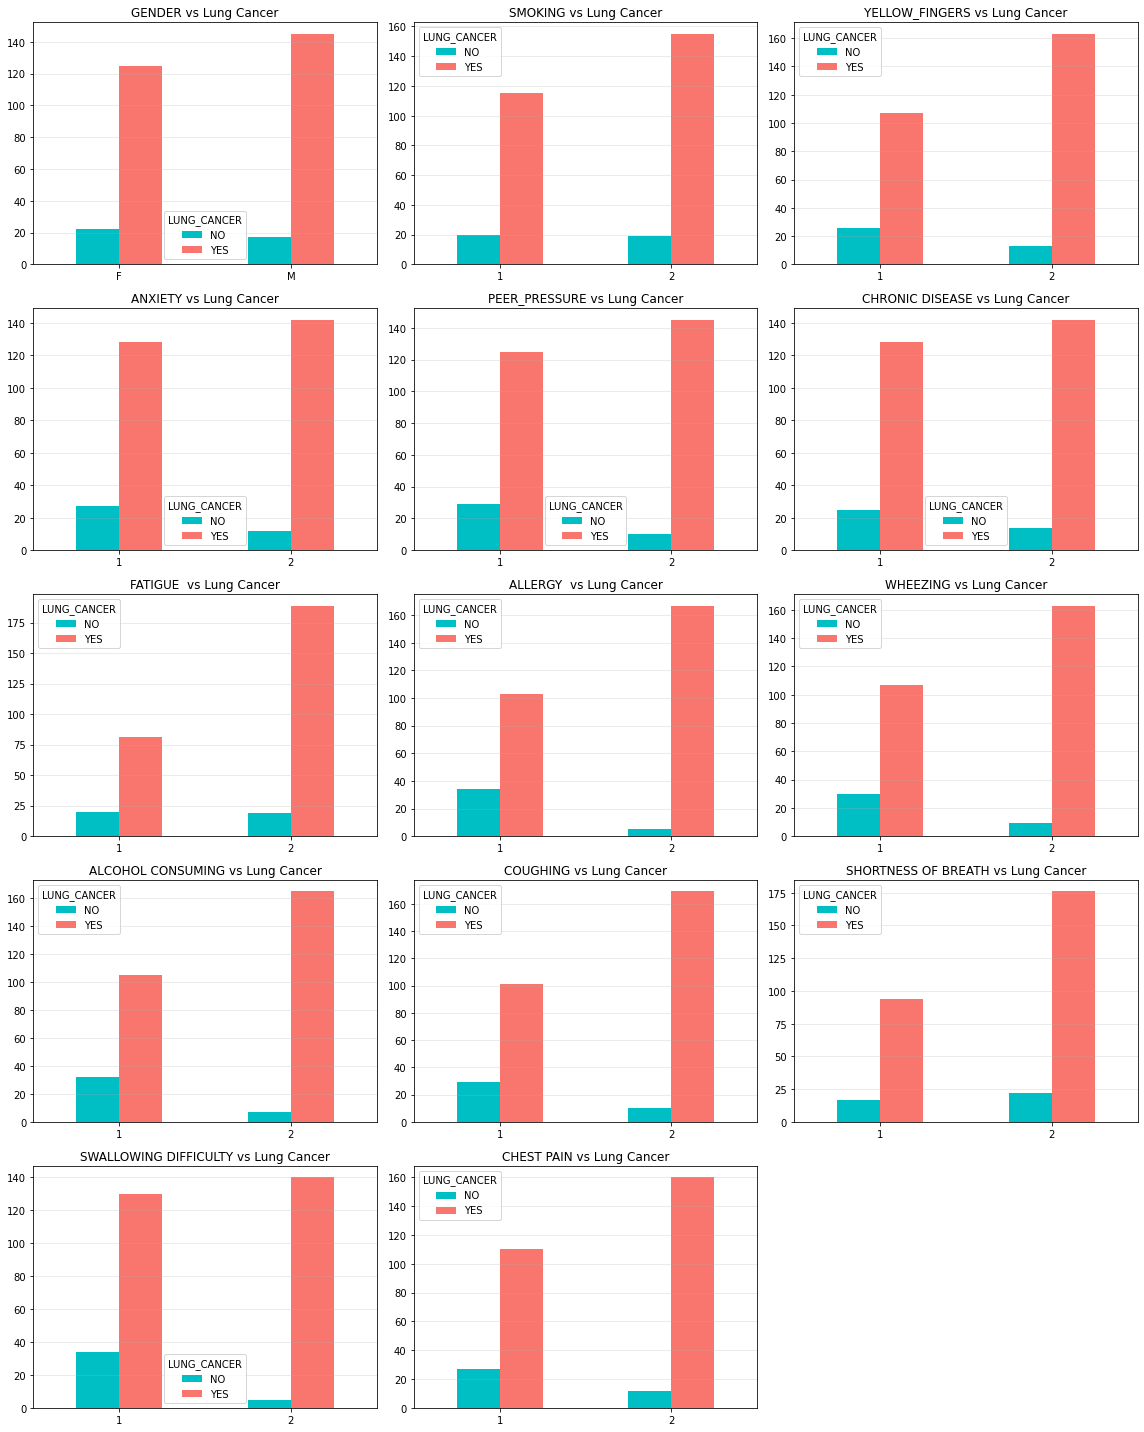

In [57]:
import math

n = len(categorical_cols)
rows = math.ceil(n / 3)

plt.figure(figsize=(16, rows * 4))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, 3, i)
    ct = pd.crosstab(df[col], df["LUNG_CANCER"])
    ct.plot(kind="bar", ax=plt.gca(), color=["#00BFC4", "#F8766D"])
    plt.title(f"{col} vs Lung Cancer")
    plt.xticks(rotation=0)
    plt.xlabel("")
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

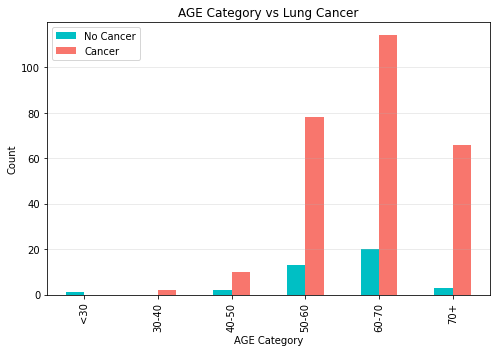

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(df["AGE_BIN"], df["LUNG_CANCER"])

ct.plot(kind="bar", figsize=(7,5), color=["#00BFC4", "#F8766D"])
plt.title("AGE Category vs Lung Cancer")
plt.xlabel("AGE Category")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.legend(["No Cancer","Cancer"])
plt.tight_layout()
plt.show()


In [63]:
import pandas as pd
from scipy.stats import ttest_ind

# Split age into two groups based on lung cancer status
age_yes = df[df["LUNG_CANCER"] == "YES"]["AGE"]
age_no = df[df["LUNG_CANCER"] == "NO"]["AGE"]

# Perform independent t-test
t_stat, p_value = ttest_ind(age_yes, age_no, equal_var=False)  # Welch's t-test

print("=== t-test result ===")
print("T-test Statistic:", t_stat)
print("P-value:", p_value)


=== t-test result ===
T-test Statistic: 1.366213567102624
P-value: 0.17853961810400154


In [69]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load dataset
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# Convert all YES/NO columns to categorical (object type)
for col in df.columns:
    if df[col].dtype != 'object':   # if numeric, convert back to category
        df[col] = df[col].astype('category')

# Now get ALL categorical columns
categorical_columns = [col for col in df.columns if col != "AGE"]

# Target variable
target = "LUNG_CANCER"

print("\n=== CHI-SQUARE TEST RESULTS FOR ALL CATEGORICAL VARIABLES ===\n")

for col in categorical_columns:
    if col != target:

        table = pd.crosstab(df[col], df[target])

        chi2, p, dof, expected = chi2_contingency(table)

        print(f"Feature: {col}")
        print("Chi-square value:", round(chi2, 3))
        print("p-value:", round(p, 4))
        print("Degrees of freedom:", dof)

        if p < 0.05:
            print("➡ Significant relationship with Lung Cancer (Reject H0)")
        else:
            print("➡ NOT Significant (Fail to Reject H0)")

        print("-" * 60)



=== CHI-SQUARE TEST RESULTS FOR ALL CATEGORICAL VARIABLES ===

Feature: GENDER
Chi-square value: 1.022
p-value: 0.3122
Degrees of freedom: 1
➡ NOT Significant (Fail to Reject H0)
------------------------------------------------------------
Feature: SMOKING
Chi-square value: 0.723
p-value: 0.3953
Degrees of freedom: 1
➡ NOT Significant (Fail to Reject H0)
------------------------------------------------------------
Feature: YELLOW_FINGERS
Chi-square value: 9.088
p-value: 0.0026
Degrees of freedom: 1
➡ Significant relationship with Lung Cancer (Reject H0)
------------------------------------------------------------
Feature: ANXIETY
Chi-square value: 5.648
p-value: 0.0175
Degrees of freedom: 1
➡ Significant relationship with Lung Cancer (Reject H0)
------------------------------------------------------------
Feature: PEER_PRESSURE
Chi-square value: 9.642
p-value: 0.0019
Degrees of freedom: 1
➡ Significant relationship with Lung Cancer (Reject H0)
-----------------------------------------


=== FINAL MODEL COMPARISON TABLE ===

                 Model  Accuracy       AUC  Sensitivity  Specificity
0  Logistic Regression  0.903226  0.949074     0.962963        0.500
1         SVM (Linear)  0.903226  0.949074     0.944444        0.625
2        Decision Tree  0.870968  0.943287     0.888889        0.750
3        Random Forest  0.919355  0.946759     0.944444        0.750
4              XGBoost  0.870968  0.923611     0.907407        0.625
5            ANN (MLP)  0.887097  0.942130     0.925926        0.625
6          Naive Bayes  0.854839  0.937500     0.907407        0.500


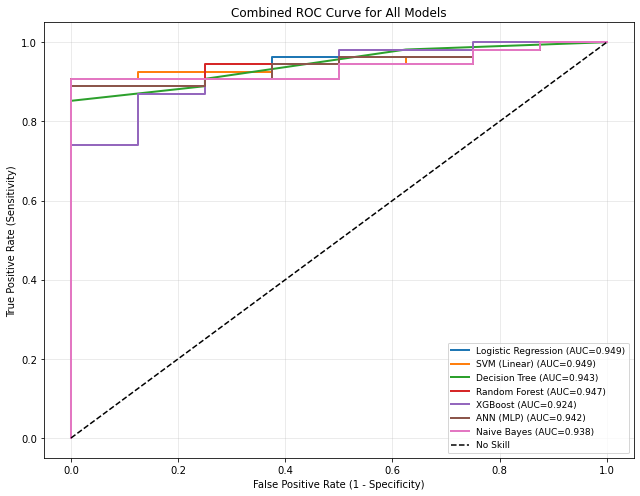

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score

# ============================
# 1. Load Dataset
# ============================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# ============================
# 2. Encode Categorical Columns
# ============================
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# 3. Split Features & Target
# ============================
X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ============================
# 4. Scale Data for ANN
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================
# 5. Define All Models
# ============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel='linear', probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "ANN (MLP)": MLPClassifier(hidden_layer_sizes=(16,12,8), max_iter=500, random_state=42),
    "Naive Bayes": GaussianNB()
}

# NOTE: ANN uses scaled data, others use normal
scaled_models = ["ANN (MLP)"]

# ============================
# 6. Storage for Comparison Table
# ============================
results = {
    "Model": [], "Accuracy": [], "AUC": [],
    "Sensitivity": [], "Specificity": []
}

# For combined ROC plot
roc_curves = {}

# ============================
# 7. Train and Evaluate All Models
# ============================
for name, model in models.items():

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    fpr, tpr, th = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Save for table
    results["Model"].append(name)
    results["Accuracy"].append(acc)
    results["AUC"].append(roc_auc)
    results["Sensitivity"].append(sensitivity)
    results["Specificity"].append(specificity)

    # Save for ROC plot
    roc_curves[name] = (fpr, tpr, roc_auc)

# ============================
# 8. Final Comparison Table
# ============================
comparison_df = pd.DataFrame(results)
print("\n=== FINAL MODEL COMPARISON TABLE ===\n")
print(comparison_df)

# ============================
# 9. Combined ROC Curve Plot
# ============================
plt.figure(figsize=(9,7))

for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="No Skill")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Combined ROC Curve for All Models")
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [77]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# Encode categorical variables
df_encoded = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# ============================
# IV Calculation Function
# ============================
def calc_iv(df, feature, target):
    lst = []

    for val in df[feature].unique():
        t = df[df[feature] == val]
        good = sum(t[target] == 0)
        bad = sum(t[target] == 1)
        lst.append([val, good, bad])

    iv_df = pd.DataFrame(lst, columns=['Value','Good','Bad'])
    iv_df['Distr_Good'] = iv_df['Good'] / iv_df['Good'].sum()
    iv_df['Distr_Bad'] = iv_df['Bad'] / iv_df['Bad'].sum()
    iv_df['WOE'] = np.log(iv_df['Distr_Bad'] / iv_df['Distr_Good'])
    iv_df['IV'] = (iv_df['Distr_Bad'] - iv_df['Distr_Good']) * iv_df['WOE']

    return iv_df['IV'].sum()

# ============================
# Calculate IV for all features
# ============================
iv_scores = {}
for col in df_encoded.drop("LUNG_CANCER", axis=1).columns:
    iv_scores[col] = calc_iv(df_encoded, col, "LUNG_CANCER")

iv_df = pd.DataFrame(iv_scores.items(), columns=["Feature", "IV"]).sort_values(by="IV", ascending=False)

print("\n=== INFORMATION VALUE TABLE ===\n")
print(iv_df)


=== INFORMATION VALUE TABLE ===

                  Feature        IV
1                     AGE       inf
8                ALLERGY   1.176844
10      ALCOHOL CONSUMING  0.851081
13  SWALLOWING DIFFICULTY  0.777126
9                WHEEZING  0.605979
11               COUGHING  0.583646
5           PEER_PRESSURE  0.340437
14             CHEST PAIN  0.337785
3          YELLOW_FINGERS  0.301211
4                 ANXIETY  0.199624
7                FATIGUE   0.191239
6         CHRONIC DISEASE  0.114131
0                  GENDER  0.041088
12    SHORTNESS OF BREATH  0.032411
2                 SMOKING  0.030395


# FEATURE IMP COMPARISION TABLE 

In [81]:
fi_table = pd.DataFrame({
    "Feature": X.columns,
    "Logistic_Reg": np.abs(models["Logistic Regression"].coef_[0]),
    "SVM": np.abs(models["SVM (Linear)"].coef_[0]),
    "Decision_Tree": models["Decision Tree"].feature_importances_,
    "Random_Forest": models["Random Forest"].feature_importances_,
    "XGBoost": models["XGBoost"].feature_importances_
})

fi_table = fi_table.sort_values(by="Random_Forest", ascending=False)

print("\n=== FEATURE IMPORTANCE COMPARISON TABLE ===\n")
print(fi_table)


=== FEATURE IMPORTANCE COMPARISON TABLE ===

                  Feature  Logistic_Reg       SVM  Decision_Tree  \
1                     AGE      0.011474  0.000066       0.088637   
8                ALLERGY       1.451985  0.930152       0.223811   
10      ALCOHOL CONSUMING      1.370438  1.042883       0.199221   
5           PEER_PRESSURE      1.296486  1.154430       0.216398   
3          YELLOW_FINGERS      0.883705  0.824645       0.007437   
7                FATIGUE       1.460646  1.176932       0.064153   
6         CHRONIC DISEASE      1.423098  1.345315       0.000000   
9                WHEEZING      0.809564  0.823277       0.000000   
11               COUGHING      0.893073  0.873418       0.000000   
4                 ANXIETY      0.611011  0.344386       0.000000   
12    SHORTNESS OF BREATH      0.052230  0.247968       0.000000   
14             CHEST PAIN      0.514265  0.493055       0.000000   
13  SWALLOWING DIFFICULTY      1.082735  0.760758       0.200344   
0 

# TOP 5 FEATURES

In [82]:
# Normalize each importance column
fi_norm = fi_table.copy()
for col in ["Logistic_Reg","SVM","Decision_Tree","Random_Forest","XGBoost"]:
    fi_norm[col] = fi_norm[col] / fi_norm[col].max()

# Add IV values
fi_norm = fi_norm.merge(iv_df, on="Feature")

# Normalize IV also
fi_norm["IV_norm"] = fi_norm["IV"] / fi_norm["IV"].max()

# Final combined score
fi_norm["Final_Score"] = fi_norm[["Logistic_Reg","SVM","Decision_Tree","Random_Forest","XGBoost","IV_norm"]].mean(axis=1)

top5 = fi_norm.sort_values(by="Final_Score", ascending=False).head(5)

print("\n=== TOP 5 FEATURES (Combined Score) ===\n")
print(top5)



=== TOP 5 FEATURES (Combined Score) ===

                  Feature  Logistic_Reg       SVM  Decision_Tree  \
1                ALLERGY       0.994070  0.691401       1.000000   
3           PEER_PRESSURE      0.887611  0.858111       0.966878   
2       ALCOHOL CONSUMING      0.938241  0.775196       0.890129   
12  SWALLOWING DIFFICULTY      0.741271  0.565487       0.895149   
5                FATIGUE       1.000000  0.874837       0.286640   

    Random_Forest   XGBoost        IV   IV_norm  Final_Score  
1        0.440674  1.000000  1.176840  0.266171     0.732053  
3        0.390223  0.521235  0.340436  0.076998     0.616843  
2        0.414942  0.441410  0.851078  0.192492     0.608735  
12       0.212341  0.567444  0.777123  0.175766     0.526243  
5        0.269338  0.264575  0.191238  0.043253     0.456441  



==== INFORMATION VALUE TABLE ====

                  Feature        IV
1                     AGE  4.421362
8                ALLERGY   1.176840
10      ALCOHOL CONSUMING  0.851078
13  SWALLOWING DIFFICULTY  0.777123
9                WHEEZING  0.605978
11               COUGHING  0.583645
5           PEER_PRESSURE  0.340436
14             CHEST PAIN  0.337784
3          YELLOW_FINGERS  0.301210
4                 ANXIETY  0.199624
7                FATIGUE   0.191238
6         CHRONIC DISEASE  0.114130
0                  GENDER  0.041088
12    SHORTNESS OF BREATH  0.032411
2                 SMOKING  0.030394

==== AVERAGE FEATURE IMPORTANCE TABLE ====

                  Feature        LR       SVM        RF       XGB       ANN  \
8                ALLERGY   1.451985  0.484426  0.089843  0.171039  0.164532   
7                FATIGUE   1.460646  0.885845  0.054911  0.055156  0.201725   
6         CHRONIC DISEASE  1.423098  0.874992  0.054584  0.056511  0.232134   
10      ALCOHOL CONSUMING  

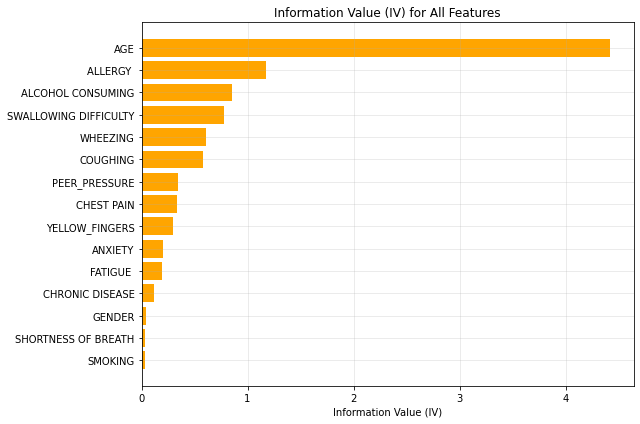

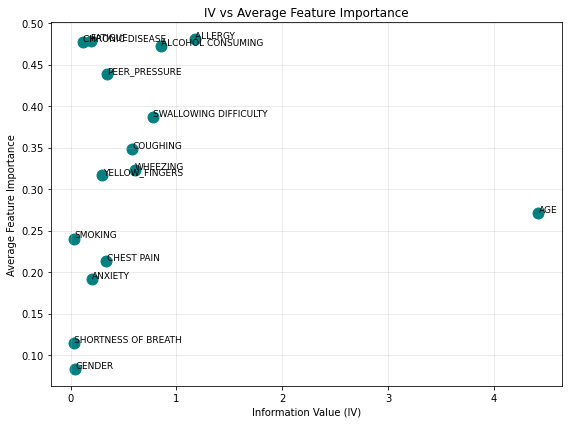

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# ============================================================
# 1. LOAD DATASET
# ============================================================
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Documents/INTERNSHIP/survey lung cancer.csv")

# Encode categorical variables
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop("LUNG_CANCER", axis=1)
y = df_encoded["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# ============================================================
# 2. INFORMATION VALUE (IV) FUNCTION
# ============================================================
def calculate_iv(df, feature, target):
    df = df[[feature, target]].copy()
    df["count"] = 1
    grouped = df.groupby(feature).agg({target: ["sum", "count"]})

    grouped.columns = ["bad", "total"]
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    grouped["dist_good"] = grouped["good"] / total_good
    grouped["dist_bad"] = grouped["bad"] / total_bad

    grouped["WOE"] = np.log((grouped["dist_good"] + 1e-6) /
                            (grouped["dist_bad"] + 1e-6))

    grouped["IV"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["WOE"]

    return grouped["IV"].sum()


# ============================================================
# 3. CALCULATE IV FOR ALL FEATURES
# ============================================================
iv_dict = {}
for feature in X.columns:
    iv_dict[feature] = calculate_iv(df_encoded, feature, "LUNG_CANCER")

iv_df = pd.DataFrame({"Feature": list(iv_dict.keys()), "IV": list(iv_dict.values())})
iv_df["IV"] = iv_df["IV"].replace([np.inf, -np.inf], np.nan)
iv_df.dropna(inplace=True)
iv_df = iv_df.sort_values(by="IV", ascending=False)

print("\n==== INFORMATION VALUE TABLE ====\n")
print(iv_df)


# ============================================================
# 4. TRAIN ALL MODELS & GET FEATURE IMPORTANCE
# ============================================================

importances = pd.DataFrame({"Feature": X.columns})

# ---- Logistic Regression ----
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
importances["LR"] = np.abs(lr.coef_[0])

# ---- SVM (Linear SVC has coefficients like LR) ----
svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)
importances["SVM"] = np.abs(svm.coef_[0])

# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
importances["RF"] = rf.feature_importances_

# ---- XGBoost ----
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
importances["XGB"] = xgb.feature_importances_

# ---- ANN (MLPClassifier) ----
mlp = MLPClassifier(hidden_layer_sizes=(20,10), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
importances["ANN"] = np.abs(mlp.coefs_[0]).mean(axis=1)

# ---- Naive Bayes (use difference between means) ----
nb = GaussianNB()
nb.fit(X_train, y_train)
importances["NB"] = np.abs(nb.theta_[1] - nb.theta_[0])


# ============================================================
# 5. AVERAGE IMPORTANCE ACROSS ALL MODELS
# ============================================================
importances["AVG_IMPORTANCE"] = importances.iloc[:, 1:].mean(axis=1)

# Sort by average importance
importances_sorted = importances.sort_values(by="AVG_IMPORTANCE", ascending=False)

print("\n==== AVERAGE FEATURE IMPORTANCE TABLE ====\n")
print(importances_sorted)

# TOP 5 FEATURES
top5 = importances_sorted.head(5)
print("\n==== TOP 5 FEATURES BASED ON AVERAGE IMPORTANCE ====\n")
print(top5)


# ============================================================
# 6. IV PLOT
# ============================================================
plt.figure(figsize=(9, 6))
plt.barh(iv_df["Feature"], iv_df["IV"], color="orange")
plt.xlabel("Information Value (IV)")
plt.title("Information Value (IV) for All Features")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 7. IV vs AVERAGE FEATURE IMPORTANCE (Scatter Plot)
# ============================================================

# Merge IV and importance
merged = pd.merge(iv_df, importances_sorted[["Feature", "AVG_IMPORTANCE"]], on="Feature")
merged = merged[merged["IV"].replace([np.inf, -np.inf], np.nan).notna()]

plt.figure(figsize=(8, 6))
plt.scatter(merged["IV"], merged["AVG_IMPORTANCE"], s=120, color="teal")

for i in range(len(merged)):
    plt.text(merged["IV"].iloc[i] + 0.002,
             merged["AVG_IMPORTANCE"].iloc[i] + 0.001,
             merged["Feature"].iloc[i],
             fontsize=9)

plt.xlabel("Information Value (IV)")
plt.ylabel("Average Feature Importance")
plt.title("IV vs Average Feature Importance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


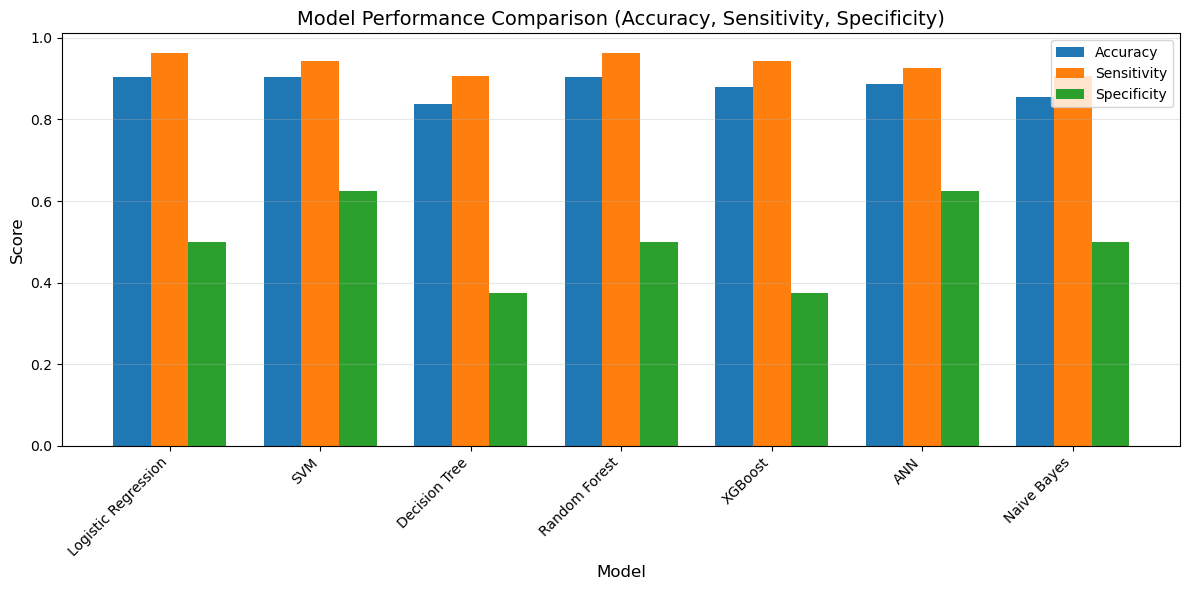

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# MODEL RESULTS
# ============================
results = {
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest", "XGBoost", "ANN", "Naive Bayes"],
    "Accuracy": [0.903, 0.903, 0.838, 0.903, 0.879, 0.887, 0.854],
    "Sensitivity": [0.963, 0.944, 0.907, 0.963, 0.944, 0.925, 0.907],
    "Specificity": [0.50, 0.625, 0.375, 0.50, 0.375, 0.625, 0.50]
}

df = pd.DataFrame(results)

# ============================
# LIGHT THEME BAR CHART
# ============================
plt.style.use("default")     # Ensure light theme

x = np.arange(len(df["Model"]))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, df["Accuracy"], width=width, label="Accuracy")
plt.bar(x, df["Sensitivity"], width=width, label="Sensitivity")
plt.bar(x + width, df["Specificity"], width=width, label="Specificity")

plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Model Performance Comparison (Accuracy, Sensitivity, Specificity)", fontsize=14)
plt.xticks(x, df["Model"], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


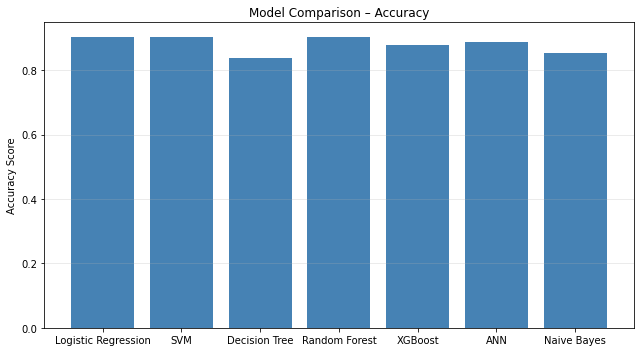

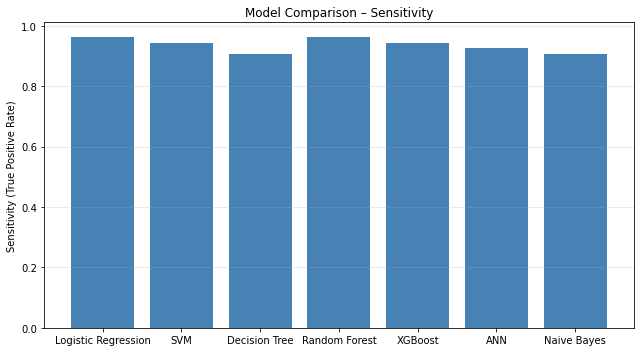

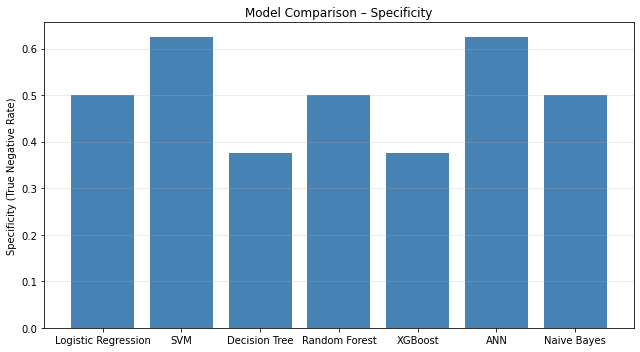

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# MODEL RESULTS
# ============================
results = {
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest", "XGBoost", "ANN", "Naive Bayes"],
    "Accuracy": [0.903, 0.903, 0.838, 0.903, 0.879, 0.887, 0.854],
    "Sensitivity": [0.963, 0.944, 0.907, 0.963, 0.944, 0.925, 0.907],
    "Specificity": [0.50, 0.625, 0.375, 0.50, 0.375, 0.625, 0.50]
}

df = pd.DataFrame(results)

# ============================
# Separate Bar Charts
# ============================

# --- Accuracy Chart ---
plt.figure(figsize=(9,5))
plt.bar(df["Model"], df["Accuracy"], color="steelblue")
plt.title("Model Comparison – Accuracy")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Sensitivity Chart ---
plt.figure(figsize=(9,5))
plt.bar(df["Model"], df["Sensitivity"], color="steelblue")
plt.title("Model Comparison – Sensitivity")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Specificity Chart ---
plt.figure(figsize=(9,5))
plt.bar(df["Model"], df["Specificity"], color="steelblue")
plt.title("Model Comparison – Specificity")
plt.ylabel("Specificity (True Negative Rate)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()